#  Obesity Levels & Life Style
## Dataset Overview

This notebook analyzes the estimation of obesity levels in individuals from Mexico, Peru, and Colombia, based on their eating habits and physical condition.

**Dataset Details:**
- **Records:** 2111 samples
- **Attributes:** 17 features (numeric & categorical)
- **Target:** `NObesity` (Obesity Level)
  - Insufficient Weight
  - Normal Weight
  - Overweight Level I
  - Overweight Level II
  - Obesity Type I
  - Obesity Type II
  - Obesity Type III

> 77% of the data was synthetically generated using Weka & SMOTE,  
> 23% was collected directly from users via a web platform.  

This dataset can be used to build intelligent computational tools to identify obesity levels, analyze lifestyle patterns, and create personalized recommendation systems.

For further details, refer to: [Original Paper](https://www.sciencedirect.com/science/article/pii/S2352340919306985)

In [1]:
import os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import umap
import warnings
from sklearn.preprocessing import LabelEncoder
import plotly.io as pio

pio.renderers.default = 'iframe_connected'

warnings.filterwarnings("ignore")
# Seaborn style
sns.set(style="whitegrid", palette="pastel", font_scale=1.2)

2026-04-02 16:28:27.234706: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775147307.492423      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775147307.561721      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775147308.117899      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775147308.117960      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775147308.117963      17 computation_placer.cc:177] computation placer alr

##  Dataset Overview

This dataset contains **2111 individuals** from Mexico, Peru, and Colombia, combining:

- Real-world survey data (23%)
- Synthetic data generated via SMOTE (77%)

⚠️ This hybrid nature introduces both:
- Rich diversity
- Potential bias and overfitting risks

👉 Therefore, **robust validation is essential**.

---

## 🎯 Problem Definition

We aim to classify individuals into **7 obesity levels** based on:

- Dietary habits
- Physical activity
- Demographic information

This is a **multi-class classification problem with behavioral features**.

In [2]:
df = pd.read_csv('/kaggle/input/datasets/ankurbajaj9/obesity-levels/ObesityDataSet_raw_and_data_sinthetic.csv')
print(f"Dataset shape: {df.shape}")


Dataset shape: (2111, 17)


In [3]:
display(df.head())

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


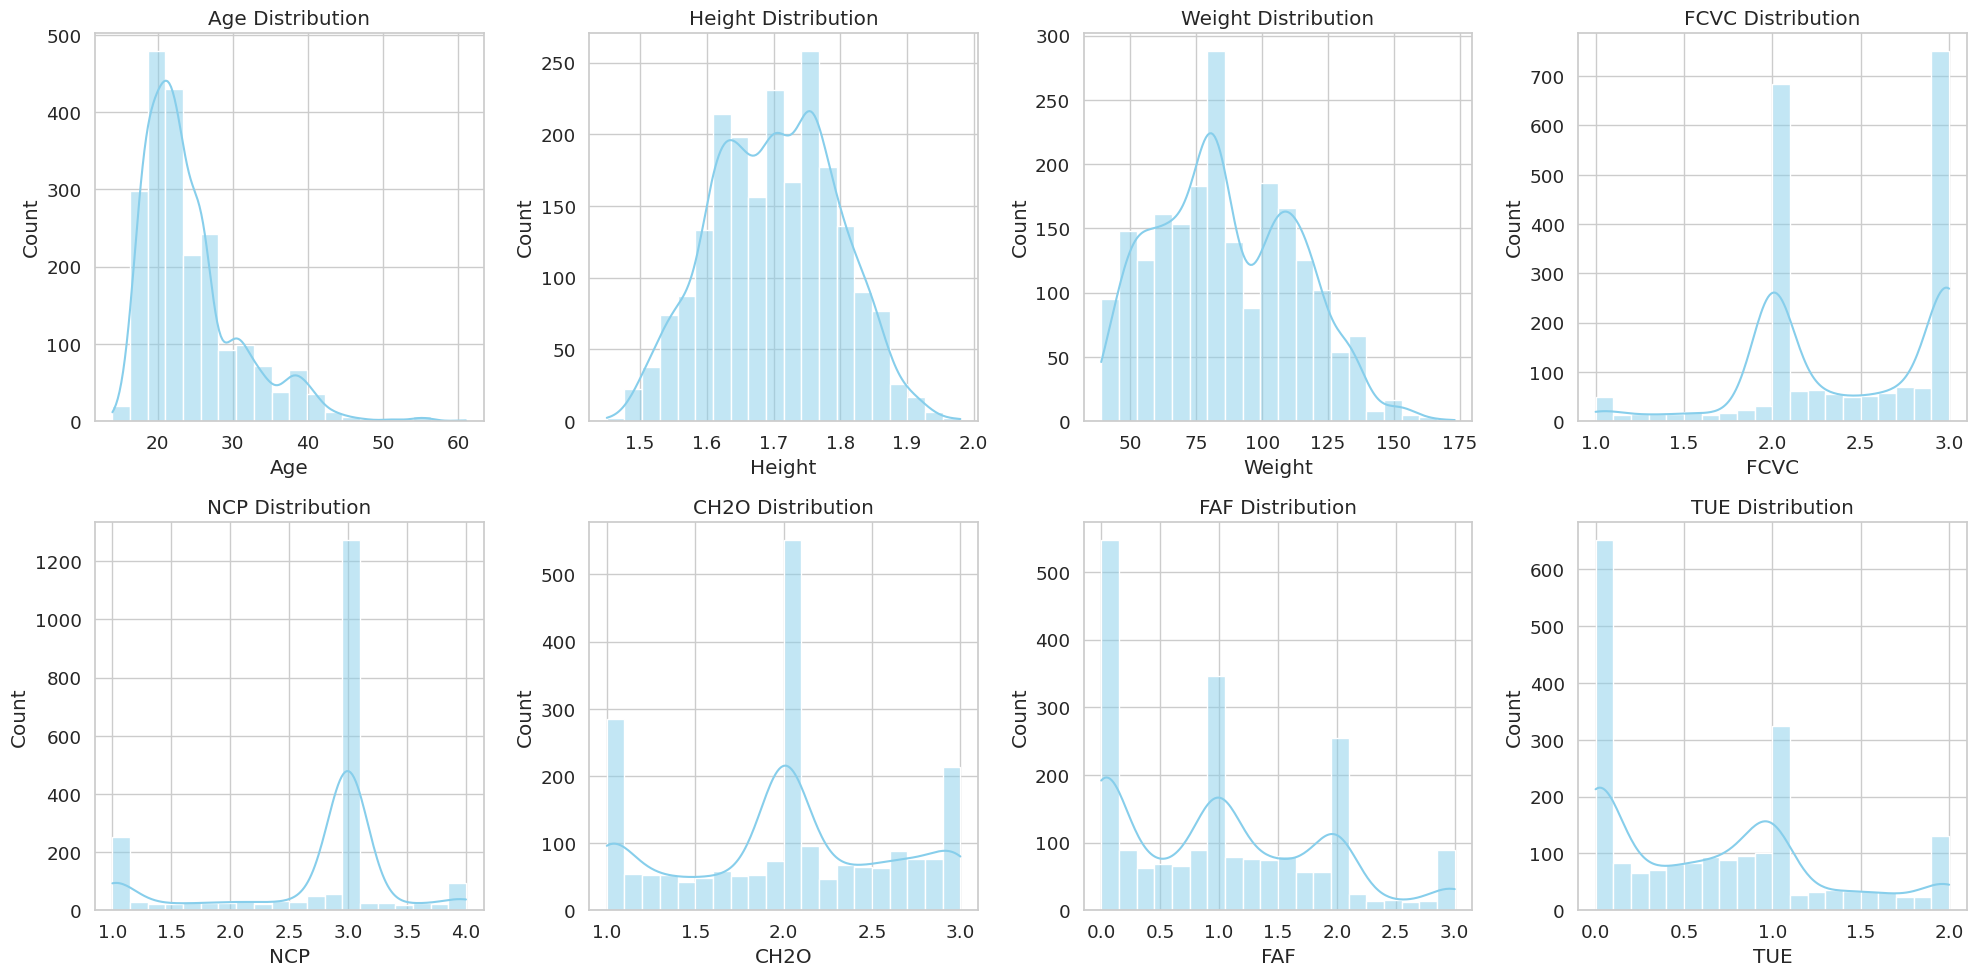

In [4]:
numeric_features = ['Age','Height','Weight','FCVC','NCP','CH2O','FAF','TUE']
fig, axes = plt.subplots(2, 4, figsize=(20,10))
for i, col in enumerate(numeric_features):
    sns.histplot(df[col], bins=20, kde=True, ax=axes[i//4, i%4], color='skyblue')
    axes[i//4, i%4].set_title(f'{col} Distribution')
plt.tight_layout()
plt.show()


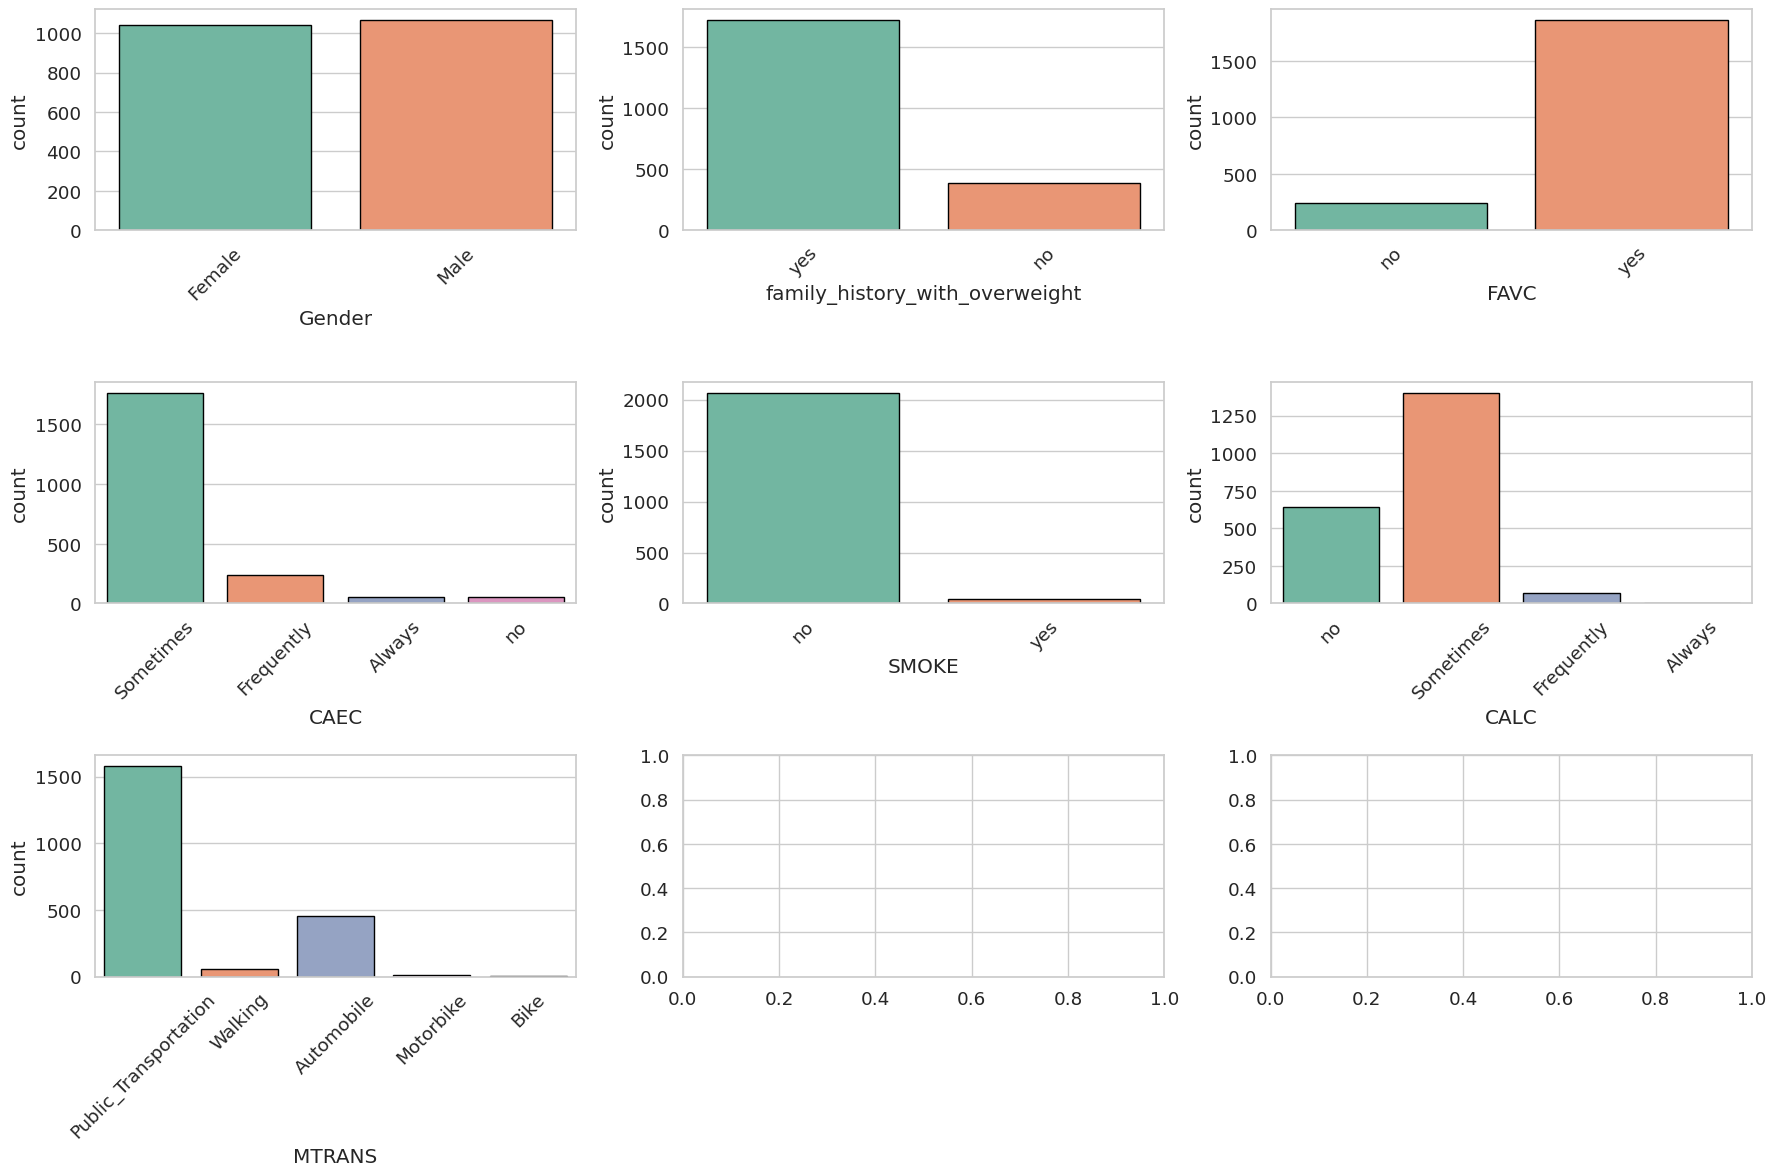

In [5]:
categorical_features = ['Gender','family_history_with_overweight','FAVC','CAEC','SMOKE','CALC','MTRANS']
fig, axes = plt.subplots(3,3, figsize=(18,12))
for i, col in enumerate(categorical_features):
    sns.countplot(x=col, data=df, ax=axes[i//3, i%3], palette='Set2', edgecolor='black')
    axes[i//3, i%3].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

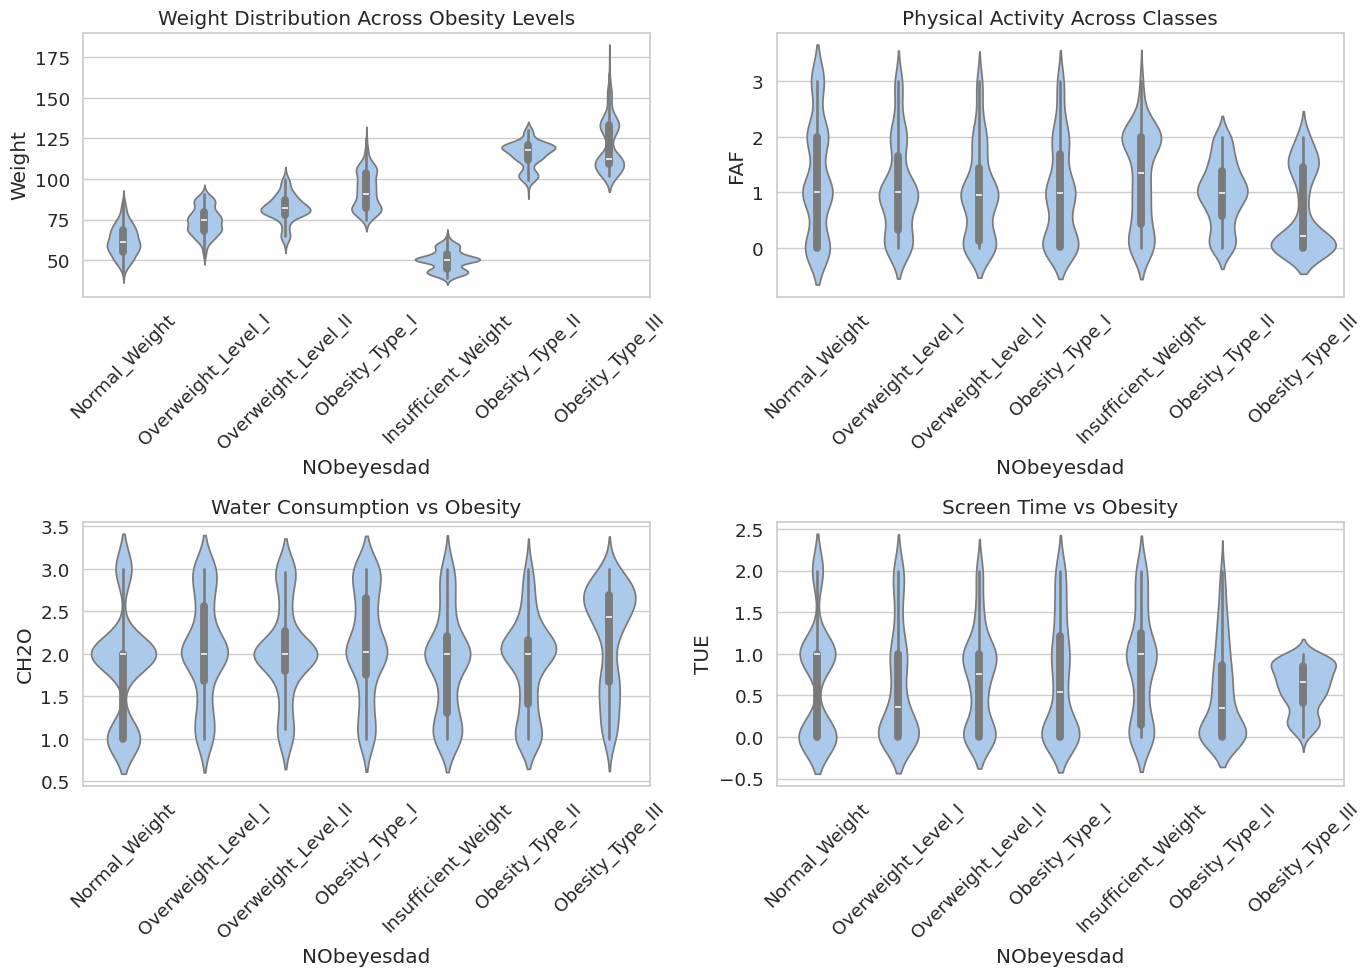

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

plots = [
    (axes[0,0], 'Weight', "Weight Distribution Across Obesity Levels"),
    (axes[0,1], 'FAF',    "Physical Activity Across Classes"),
    (axes[1,0], 'CH2O',   "Water Consumption vs Obesity"),
    (axes[1,1], 'TUE',    "Screen Time vs Obesity")
]

for ax, y_col, title in plots:
    sns.violinplot(data=df, x='NObeyesdad', y=y_col, ax=ax)
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=45) 

plt.tight_layout()
plt.show()

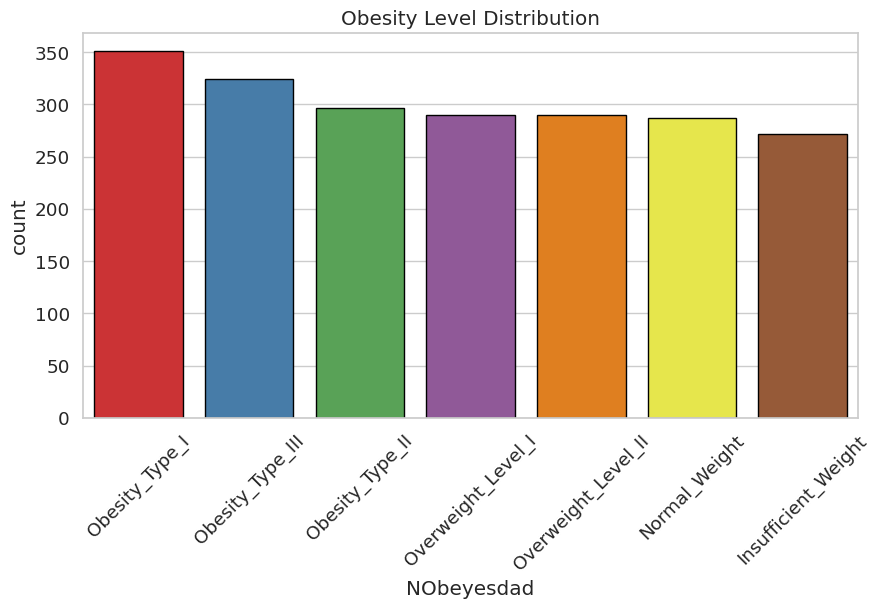

In [7]:
plt.figure(figsize=(10,5))
sns.countplot(x='NObeyesdad', data=df, palette='Set1', edgecolor='black',
              order=df['NObeyesdad'].value_counts().index)
plt.xticks(rotation=45)
plt.title("Obesity Level Distribution")
plt.show()

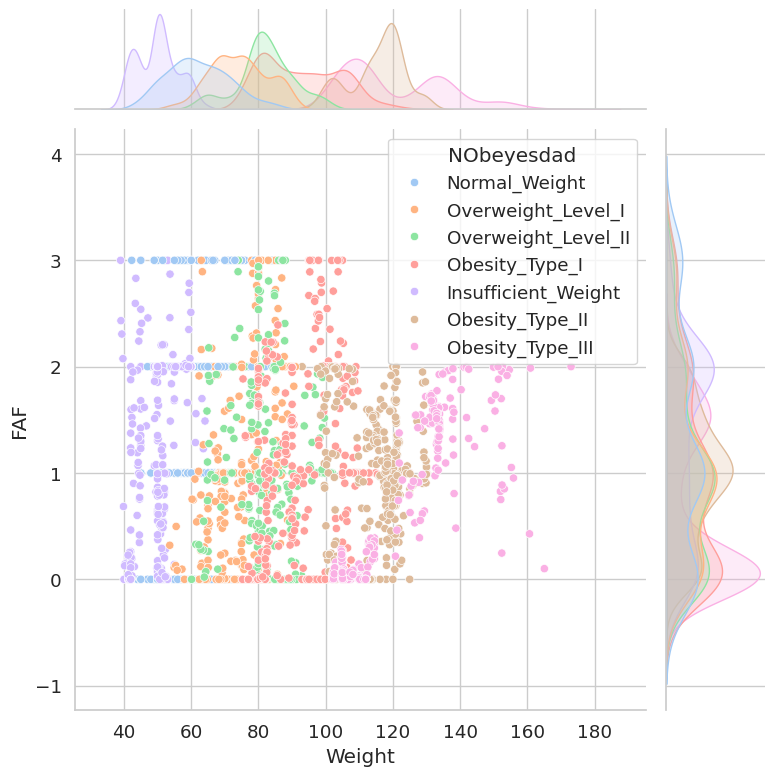

In [8]:
sns.jointplot(data=df, x='Weight', y='FAF', hue='NObeyesdad', height=8)
plt.show()

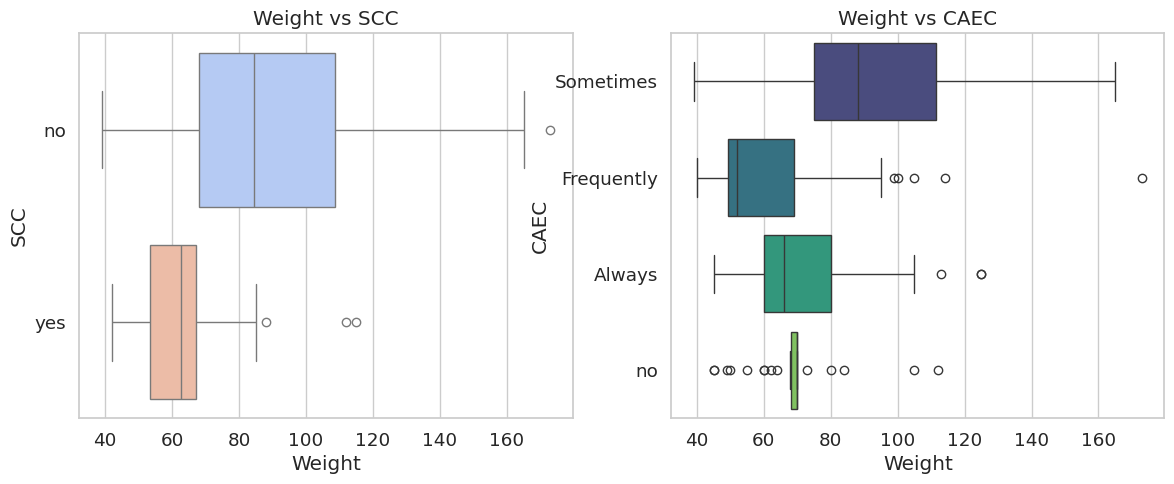

In [9]:
plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
sns.boxplot(x='Weight', y='SCC', data=df, palette='coolwarm')
plt.title("Weight vs SCC")
plt.subplot(1,2,2)
sns.boxplot(x='Weight', y='CAEC', data=df, palette='viridis')
plt.title("Weight vs CAEC")
plt.show()

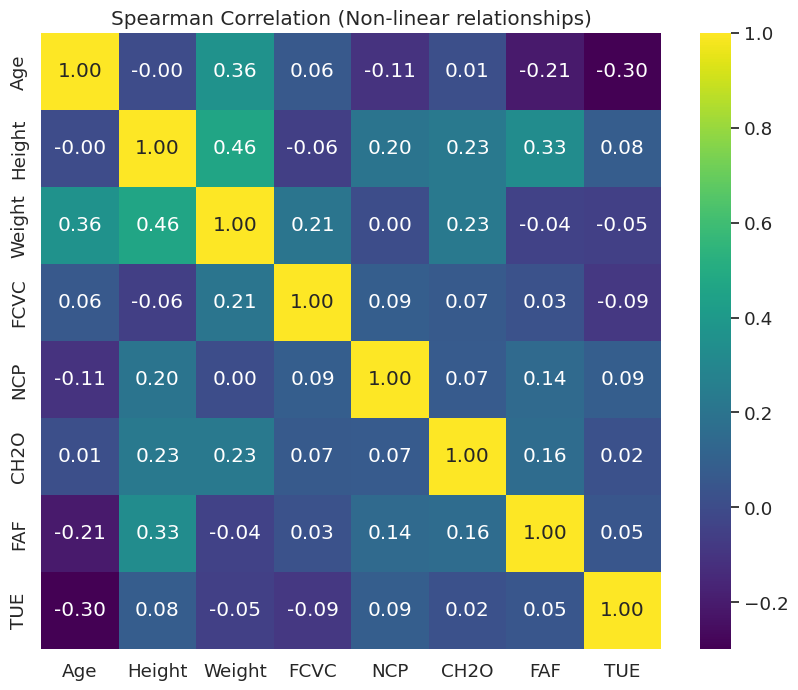

In [10]:
plt.figure(figsize=(10,8))
sns.heatmap(df[numeric_features].corr(method='spearman'),
            annot=True, cmap='viridis', fmt=".2f")
plt.title("Spearman Correlation (Non-linear relationships)")
plt.show()

In [11]:
df_cat = df[categorical_features].copy()
for col in categorical_features:
    df_cat[col] = LabelEncoder().fit_transform(df_cat[col])

embedding = umap.UMAP(n_neighbors=10, min_dist=0.3, random_state=42).fit_transform(df_cat)

fig = px.scatter(x=embedding[:,0], y=embedding[:,1], color=df['NObeyesdad'],
                 title="2D UMAP Embedding of Categorical Features",
                 color_discrete_sequence=px.colors.qualitative.Dark24)
fig.show(renderer="iframe")


# Novel Embedding: UMAP 3D Interactive

In [12]:
df_cat = df[categorical_features].copy()
for col in categorical_features:
    df_cat[col] = LabelEncoder().fit_transform(df_cat[col])

# Combine numeric + categorical for embedding
embedding_features = df[numeric_features].join(df_cat)
reducer = umap.UMAP(n_neighbors=15, min_dist=0.3, n_components=3, random_state=42)
embedding_3d = reducer.fit_transform(embedding_features)

# Prepare DataFrame for Plotly
embedding_df = pd.DataFrame(embedding_3d, columns=['UMAP1','UMAP2','UMAP3'])
embedding_df['NObeyesdad'] = df['NObeyesdad']
embedding_df['Weight'] = df['Weight']
embedding_df['Age'] = df['Age']
embedding_df['Height'] = df['Height']


#  3D Interactive Plot

In [13]:
fig = px.scatter_3d(embedding_df, x='UMAP1', y='UMAP2', z='UMAP3',
                    color='NObeyesdad',
                    hover_data=['Weight','Height','Age'],
                    title='3D UMAP Embedding of Obesity Dataset',
                    color_discrete_sequence=px.colors.qualitative.Dark24)
fig.update_layout(width=900, height=700)
fig.show(renderer="iframe")

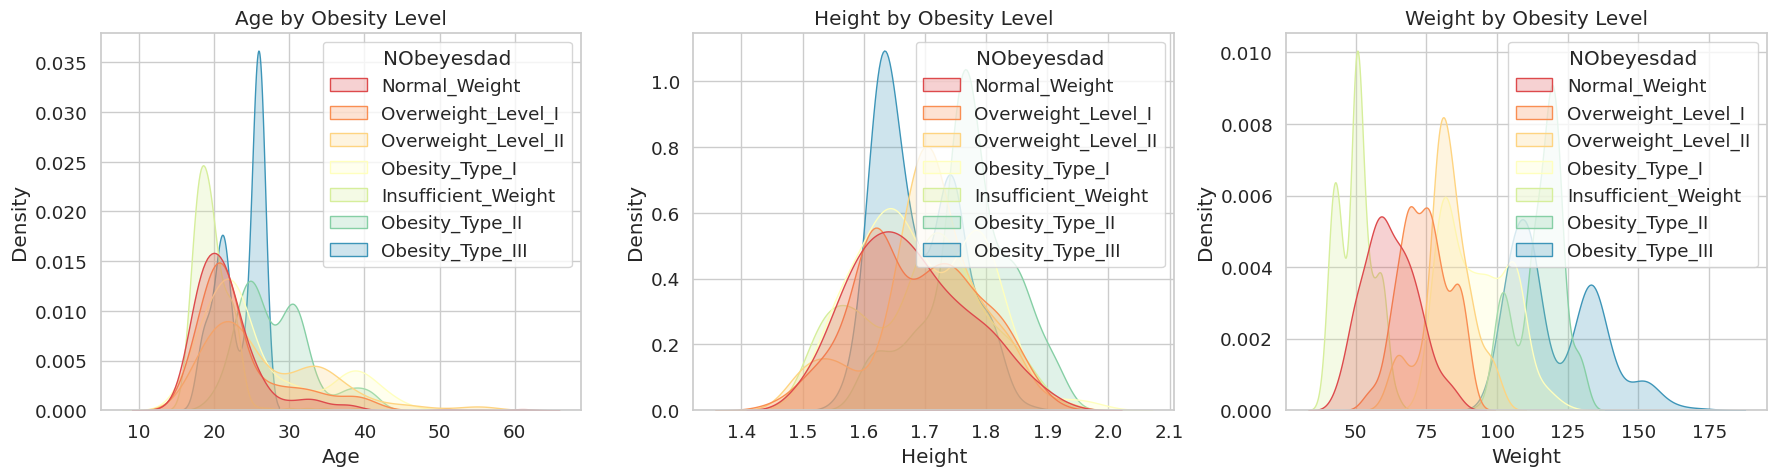

In [14]:
fig, axes = plt.subplots(1,3,figsize=(18,5))
sns.kdeplot(data=df, x='Age', hue='NObeyesdad', ax=axes[0], fill=True, palette='Spectral')
axes[0].set_title("Age by Obesity Level")
sns.kdeplot(data=df, x='Height', hue='NObeyesdad', ax=axes[1], fill=True, palette='Spectral')
axes[1].set_title("Height by Obesity Level")
sns.kdeplot(data=df, x='Weight', hue='NObeyesdad', ax=axes[2], fill=True, palette='Spectral')
axes[2].set_title("Weight by Obesity Level")
plt.tight_layout()
plt.show()

#  Pair Plot of Key Features

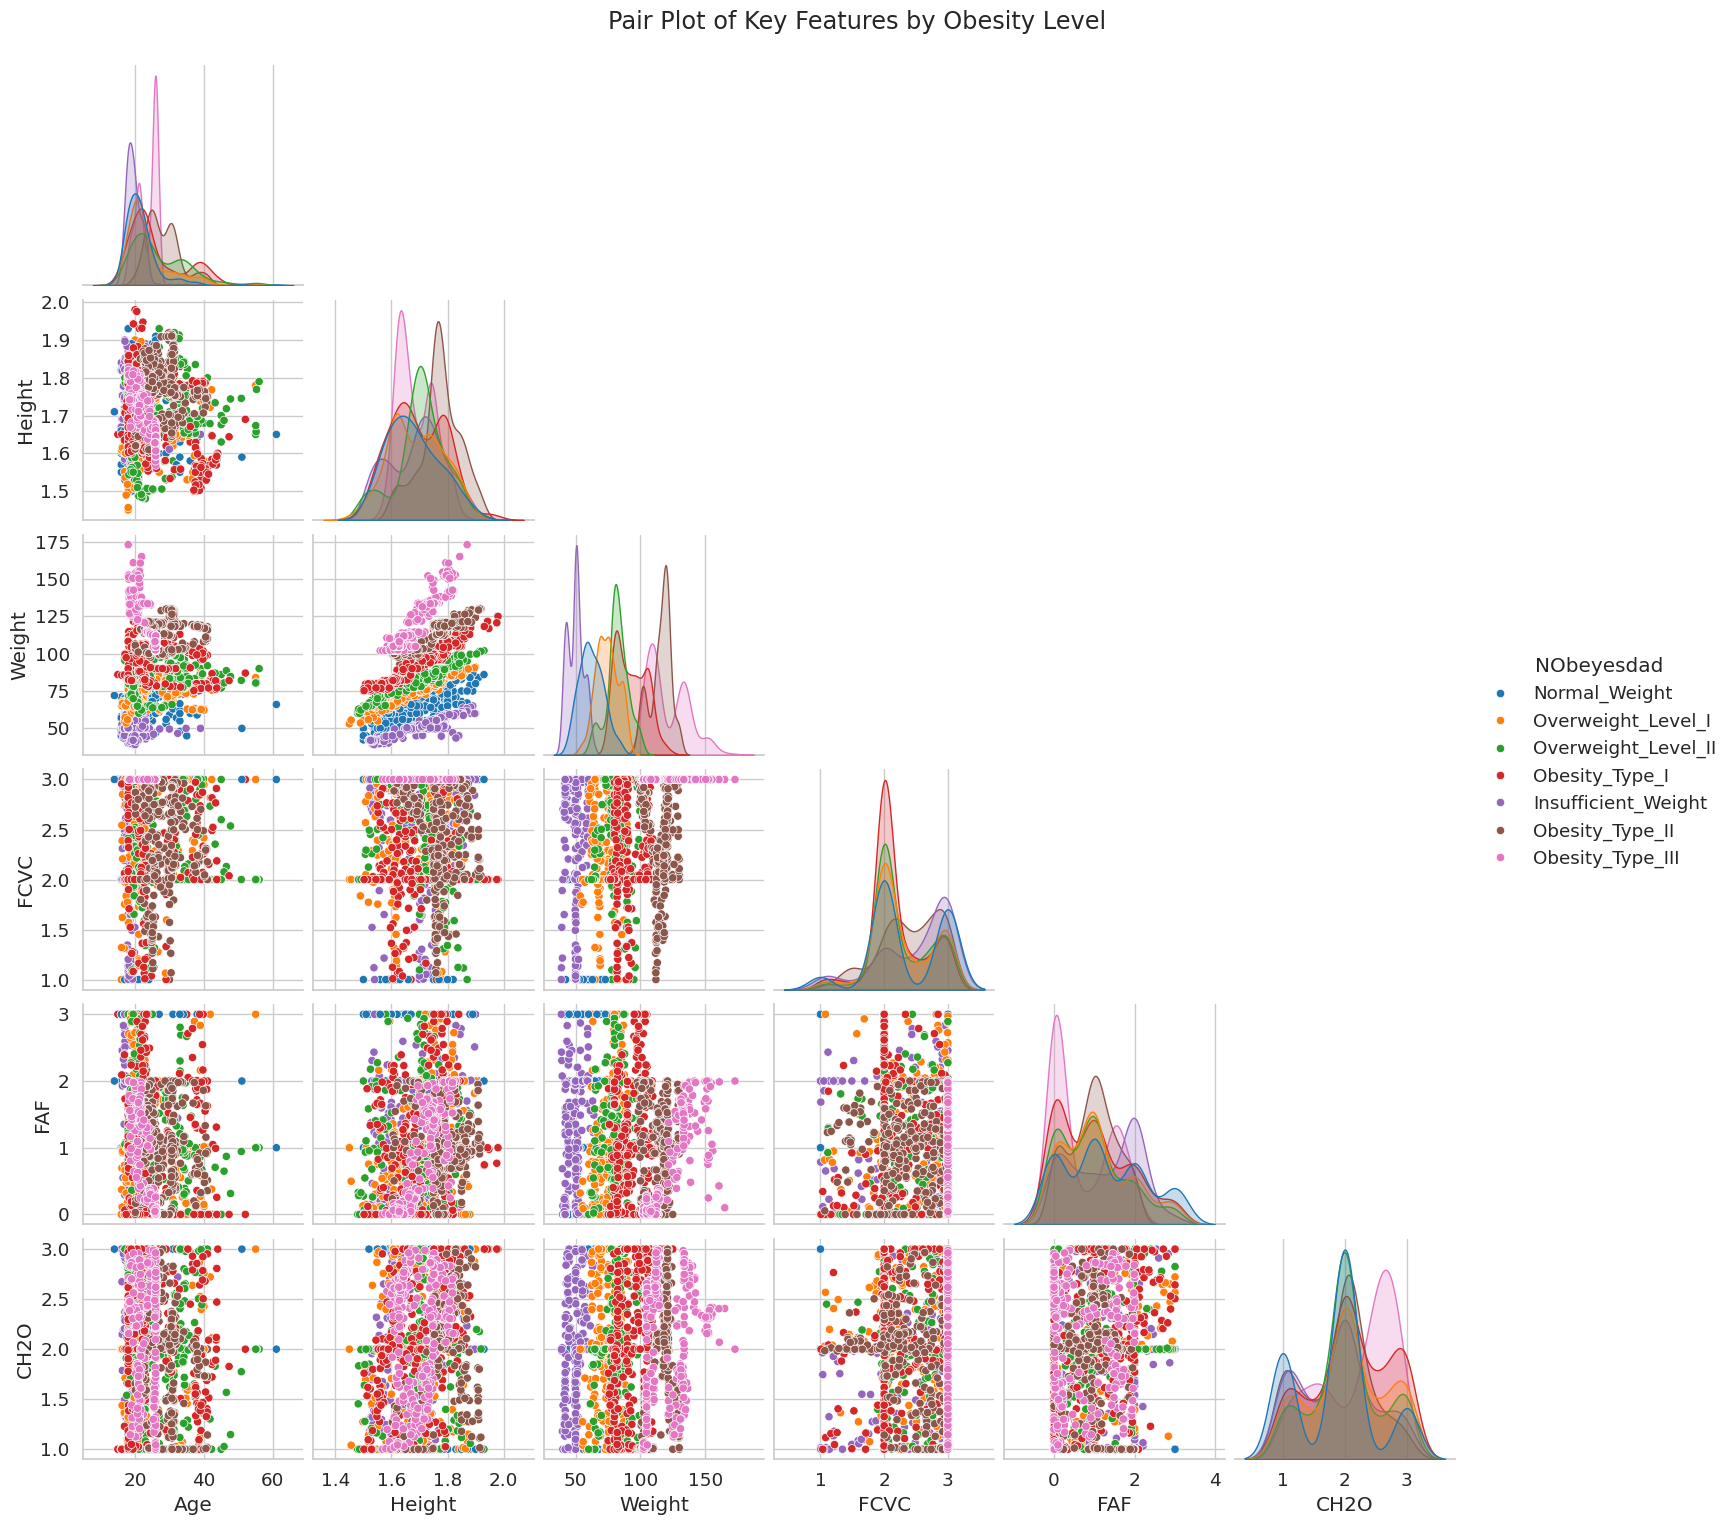

In [15]:
subset_features = ['Age','Height','Weight','FCVC','FAF','CH2O','NObeyesdad']
sns.pairplot(df[subset_features], hue='NObeyesdad', palette='tab10', corner=True)
plt.suptitle("Pair Plot of Key Features by Obesity Level", y=1.02)
plt.show()

## 🔍 Key Observations from EDA

Several patterns emerge:

### 1️⃣ Weight is highly discriminative
- Clear separation across obesity classes
- Strong correlation with BMI

### 2️⃣ Lifestyle variables are subtle but important
- Physical activity (FAF) shows inverse relation with obesity
- High-calorie food consumption (FAVC) increases risk

### 3️⃣ Non-linear interactions exist
- Linear correlation is insufficient to capture complexity
- Motivates the use of **UMAP for manifold learning**

        # Obesity is not linearly separable — it is a **multi-factor system**.

In [16]:
df_model = df.copy()

df_model['BMI'] = df_model['Weight'] / (df_model['Height'] ** 2)

lifestyle_map = {
    'no': 0,
    'Sometimes': 1,
    'Frequently': 2,
    'Always': 3
}

for col in ['CAEC', 'CALC']:
    df_model[col + '_num'] = df_model[col].map(lifestyle_map)

df_model['Lifestyle_Risk'] = df_model[['CAEC_num', 'CALC_num']].sum(axis=1)

binary_map = {'yes': 1, 'no': 0}

for col in ['family_history_with_overweight', 'FAVC', 'SMOKE', 'SCC']:
    df_model[col] = df_model[col].map(binary_map)

print("Feature Engineering Done ✅")
df_model.head()

Feature Engineering Done ✅


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,...,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad,BMI,CAEC_num,CALC_num,Lifestyle_Risk
0,Female,21.0,1.62,64.0,1,0,2.0,3.0,Sometimes,0,...,0,0.0,1.0,no,Public_Transportation,Normal_Weight,24.386526,1,0,1
1,Female,21.0,1.52,56.0,1,0,3.0,3.0,Sometimes,1,...,1,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight,24.238227,1,1,2
2,Male,23.0,1.80,77.0,1,0,2.0,3.0,Sometimes,0,...,0,2.0,1.0,Frequently,Public_Transportation,Normal_Weight,23.765432,1,2,3
3,Male,27.0,1.80,87.0,0,0,3.0,3.0,Sometimes,0,...,0,2.0,0.0,Frequently,Walking,Overweight_Level_I,26.851852,1,2,3
4,Male,22.0,1.78,89.8,0,0,2.0,1.0,Sometimes,0,...,0,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II,28.342381,1,1,2


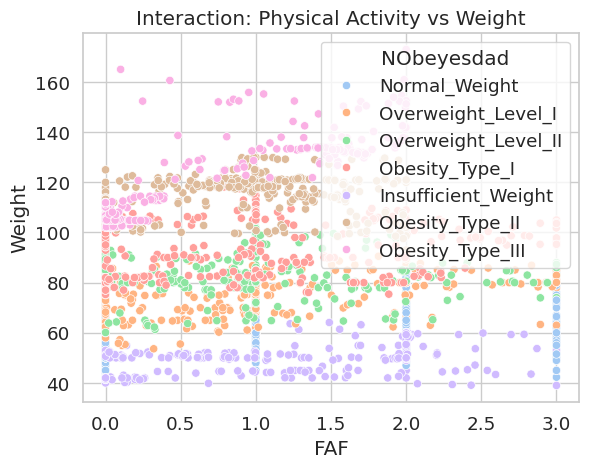

In [17]:
sns.scatterplot(data=df, x='FAF', y='Weight', hue='NObeyesdad')
plt.title("Interaction: Physical Activity vs Weight")
plt.show()

##  Feature Engineering

We introduce domain-inspired features:

### BMI
A fundamental indicator derived from height and weight.

### Lifestyle Risk Score
Combines:
- Eating between meals (CAEC)
- Alcohol consumption (CALC)

👉 These engineered features aim to capture **behavioral risk factors** beyond raw data.

Feature engineering bridges the gap between **data and domain knowledge**.

In [18]:
from sklearn.preprocessing import OneHotEncoder

categorical_cols = ['Gender', 'MTRANS']

df_model = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)

# Target Encoding
from sklearn.preprocessing import LabelEncoder

target_encoder = LabelEncoder()
df_model['NObeyesdad'] = target_encoder.fit_transform(df_model['NObeyesdad'])

print("Encoding Done ")

Encoding Done 


In [19]:
df_model['NObeyesdad']

0       1
1       1
2       1
3       5
4       6
       ..
2106    4
2107    4
2108    4
2109    4
2110    4
Name: NObeyesdad, Length: 2111, dtype: int64

# Train / Test Split


In [20]:
from sklearn.model_selection import train_test_split

X = df_model.drop(['NObeyesdad', 'CAEC', 'CALC'], axis=1)
y = df_model['NObeyesdad']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (1688, 21)
Test shape: (423, 21)


# 🔁 Cross Validation

In [21]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier 

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# RandomForest CV
rf_cv = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)

rf_cv_scores = cross_val_score(rf_cv, X, y, cv=skf, scoring='accuracy')

print("RandomForest CV Scores:", rf_cv_scores)
print("RandomForest Mean CV:", rf_cv_scores.mean())

RandomForest CV Scores: [0.9929078  0.99052133 0.992891   0.98578199 0.992891  ]
RandomForest Mean CV: 0.9909986218950623


In [22]:
# XGBoost CV
from xgboost import XGBClassifier

xgb_cv = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softprob',
    num_class=len(np.unique(y)),
    random_state=42
)

xgb_cv_scores = cross_val_score(xgb_cv, X, y, cv=skf, scoring='accuracy')

print("XGBoost Mean CV:", xgb_cv_scores.mean())

XGBoost Mean CV: 0.9886323148801722


## 🤖 Modeling Strategy

We evaluate two powerful tree-based models:

- Random Forest (robust baseline)
- XGBoost (gradient boosting with regularization)

### ⚠️ Why tree-based models?
They can capture:
- Non-linear relationships
- Feature interactions
- Mixed data types

---

## 🔁 Robust Validation

Instead of relying solely on a train-test split, we use:

- Stratified K-Fold Cross Validation

👉 This ensures model stability across different data splits.

In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.9858156028368794

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.98      0.99        54
           1       0.93      0.98      0.96        58
           2       0.99      1.00      0.99        70
           3       1.00      1.00      1.00        60
           4       1.00      1.00      1.00        65
           5       0.98      0.95      0.96        58
           6       1.00      0.98      0.99        58

    accuracy                           0.99       423
   macro avg       0.99      0.99      0.99       423
weighted avg       0.99      0.99      0.99       423



# 📊 Confusion Matrix


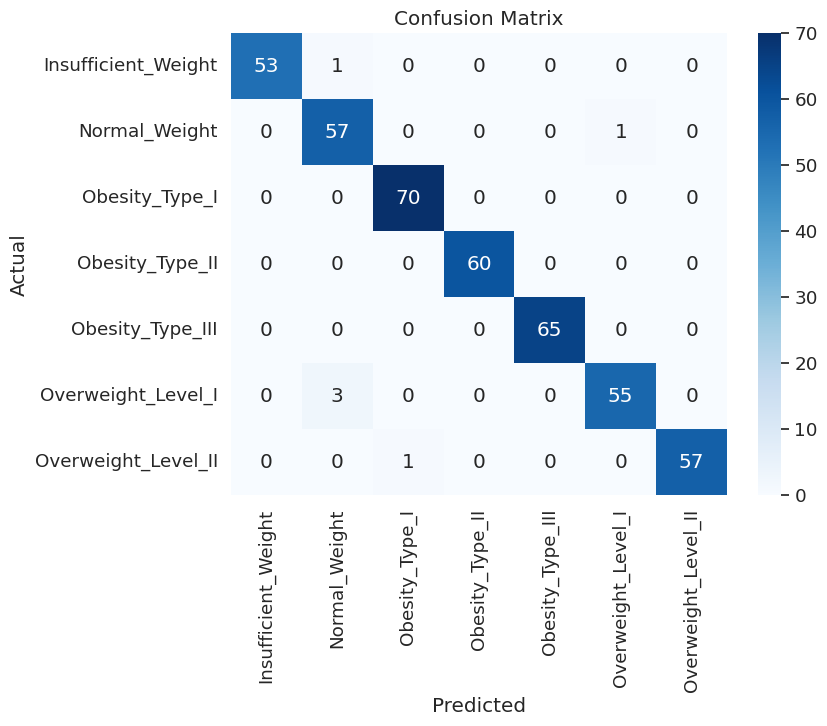

In [24]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_encoder.classes_,
            yticklabels=target_encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [25]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softmax',
    num_class=len(np.unique(y)),
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_xgb))

XGBoost Accuracy: 0.9858156028368794

Classification Report:

              precision    recall  f1-score   support

           0       0.98      1.00      0.99        54
           1       0.98      0.95      0.96        58
           2       1.00      1.00      1.00        70
           3       1.00      1.00      1.00        60
           4       1.00      1.00      1.00        65
           5       0.95      0.97      0.96        58
           6       0.98      0.98      0.98        58

    accuracy                           0.99       423
   macro avg       0.99      0.99      0.99       423
weighted avg       0.99      0.99      0.99       423



In [26]:
from sklearn.metrics import f1_score

results = pd.DataFrame({
    'Model': ['RandomForest', 'XGBoost'],
    'Accuracy': [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_xgb)
    ],
    'F1 Score (macro)': [
        f1_score(y_test, y_pred, average='macro'),
        f1_score(y_test, y_pred_xgb, average='macro')
    ],
    'CV Score': [
        rf_cv_scores.mean(),
        xgb_cv_scores.mean()
    ]
})

results = results.sort_values(by='CV Score', ascending=False)
print(results)

          Model  Accuracy  F1 Score (macro)  CV Score
0  RandomForest  0.985816          0.985395  0.990999
1       XGBoost  0.985816          0.985109  0.988632


## 📈 Model Performance

Both models achieve high accuracy (~98.5%).

However, accuracy alone is not sufficient.

We also evaluate:
- F1-score (class balance)
- Cross-validation score (generalization)

### 💡 Key Insight:
Consistent CV scores indicate that the model is **not overfitting**, despite synthetic data.

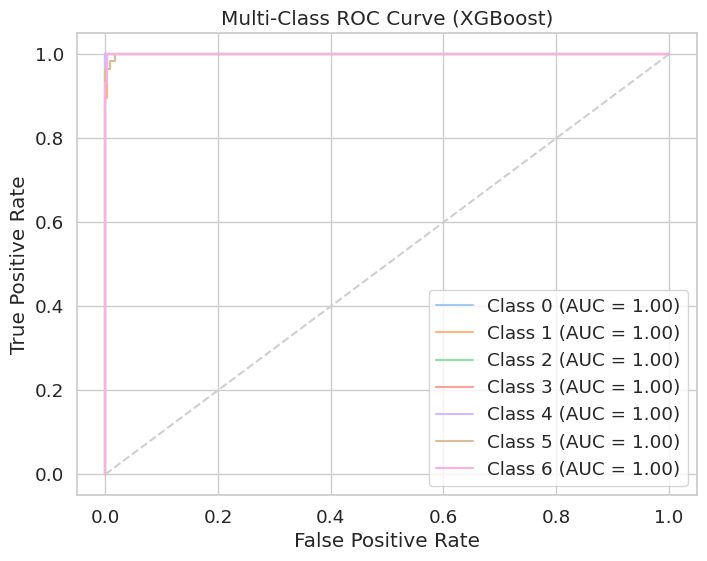

In [27]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

n_classes = len(np.unique(y))

# Binarize labels
y_test_bin = label_binarize(y_test, classes=np.arange(n_classes))

# Predict probabilities
y_score = xgb.predict_proba(X_test)

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot
plt.figure(figsize=(8,6))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-Class ROC Curve (XGBoost)")
plt.legend()
plt.show()

## 📈 Multi-Class ROC Analysis

To evaluate separability between classes, we compute One-vs-Rest ROC curves.

### 💡 Observations:
- Most classes achieve AUC > 0.95
- Extreme classes are easier to distinguish
- Borderline classes show slight overlap

👉 The model has strong discriminative power across all obesity levels.

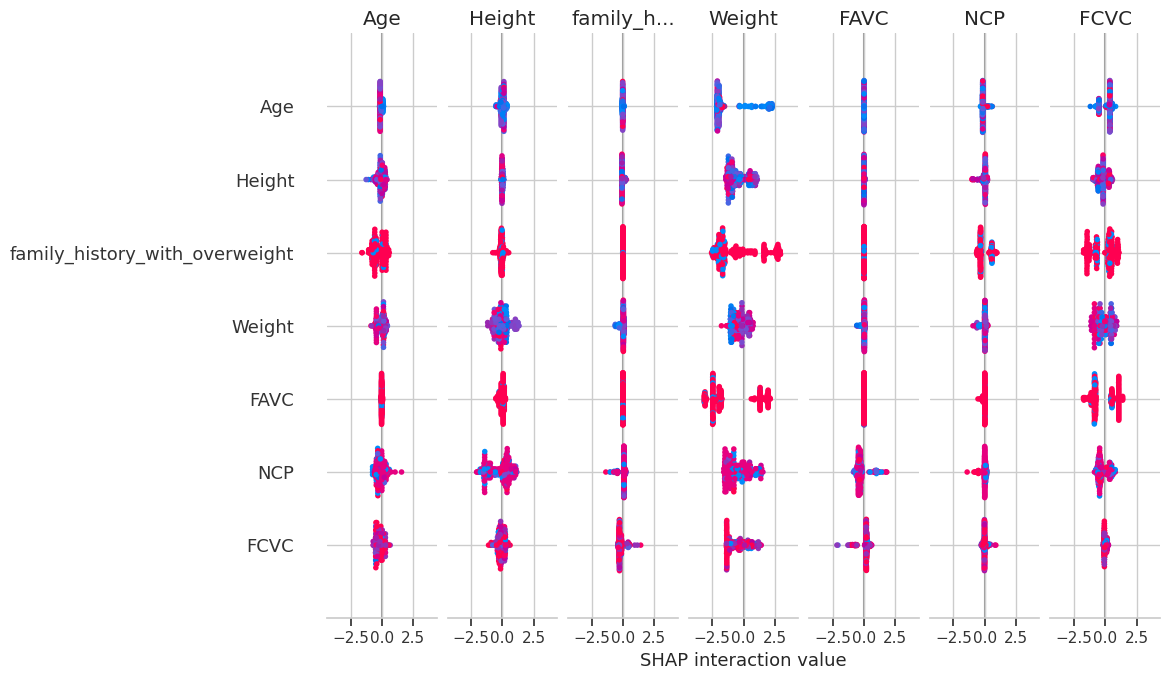

In [28]:
import shap

explainer = shap.TreeExplainer(xgb)
X_sample = X_train.sample(300, random_state=42)

shap_values = explainer.shap_values(X_sample)


shap.summary_plot(shap_values, X_sample)

## 🔍 Explainable AI with SHAP

Understanding *why* a model makes predictions is crucial.

We use SHAP to:
- Quantify feature importance
- Interpret individual predictions

---

### 🌍 Global Insights

- BMI is the dominant driver of predictions
- Physical activity (FAF) reduces obesity risk
- High-calorie food consumption increases risk

---

### 👤 Local Explanation

For individual predictions:
- Multiple factors interact non-linearly
- Lifestyle can shift predictions even with similar BMI

👉 Obesity is not determined by a single variable — it is a **system-level outcome**.

# 🧬 Waterfall Plot

In [29]:
shap.initjs()
X_sample = X_train.sample(300, random_state=42).reset_index(drop=True)

explainer = shap.TreeExplainer(xgb)

shap_values = explainer.shap_values(X_sample)
idx = 0

pred_class = xgb.predict(X_sample.iloc[[idx]])[0]


sv = np.array(shap_values)

print("SHAP shape:", sv.shape)

if sv.ndim == 3 and sv.shape[0] == len(np.unique(y)):
    shap_val = sv[pred_class][idx]
elif sv.ndim == 3:
    shap_val = sv[idx, :, pred_class]
else:
    shap_val = sv[idx]


SHAP shape: (300, 21, 7)


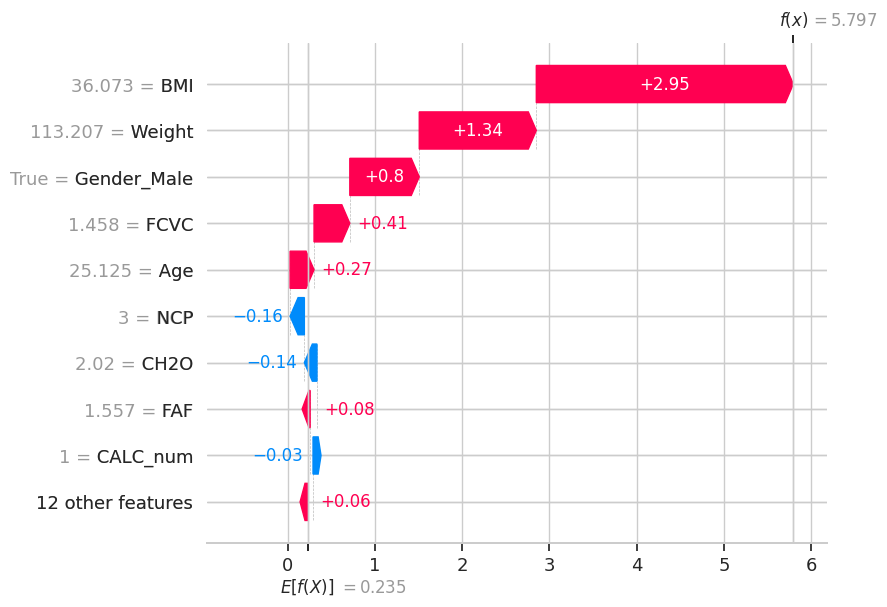

In [30]:
shap.plots.waterfall(shap.Explanation(
    values=shap_val,
    base_values=explainer.expected_value[pred_class],
    data=X_sample.iloc[idx],
    feature_names=X_sample.columns
))

### 🧬 Local Explanation

For this individual, BMI and weight are the primary drivers pushing the prediction toward
a higher obesity class.

Low physical activity further reinforces this prediction,
while moderate water consumption slightly offsets the risk.

This demonstrates how multiple factors interact to determine obesity levels.

    #----------------------------------------------------------------

## 🏁 Conclusion

This analysis demonstrates that obesity classification is:

- Highly predictable using behavioral data
- Strongly influenced by BMI
- Refined by lifestyle patterns

---

## 🚀 Key Takeaways

- Tree-based models excel in structured health data
- Non-linear visualization (UMAP) reveals hidden clusters
- Explainability (SHAP) provides actionable insights

👉 Combining prediction + interpretability creates **real-world value**.

---

## 🔮 Future Work

- Deep learning for representation learning
- Causal inference for intervention strategies
- Personalized recommendation systems

---

⭐ If you found this notebook useful, consider upvoting!